<a href="https://colab.research.google.com/github/josefanini/regressao-bnds-atividade/blob/main/Atividade_Regressao_BNDES.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Atividade de Regressão - Aprendizado de Máquina

**Aluno:** Jose Fanini Cordeiro dos Santos  
**Disciplina:** Aprendizado de Máquina  
**Professor:** Josenildo Costa da Silva  
**Data da Entrega:** 10 de Abril de 2026

## Objetivo
Analisar os fatores que influenciam o valor dos financiamentos concedidos pelo BNDES utilizando técnicas de regressão linear simples e multivariável, avaliando o impacto do prazo, localização geográfica e setor econômico na composição do crédito.

## **Acesso aos Dados e Código**
* **Dataset (GitHub):** [Link Direto para o CSV](https://github.com/josefanini/regressao-bnds-atividade/raw/refs/heads/main/operacoes-financiamento-operacoes-nao-automaticas.csv)
* **Repositório:** [Projeto Completo no GitHub](https://github.com/josefanini/regressao-bnds-atividade)

## 2. Descrição do Dataset e Preparação dos Dados (Limpeza e Transformação)

O conjunto de dados utilizado foi extraído do portal de Dados Abertos do BNDES, referente às **operações de financiamento não automáticas**. O arquivo original contém 23.289 registros e 34 colunas, abrangendo um histórico de contratações realizadas a partir de 2002.

**Processo de Preparação:** Para viabilizar a análise de regressão, foi realizada uma etapa de filtragem e limpeza, selecionando as variáveis com maior potencial preditivo e removendo registros com valores ausentes (NaN). A variável alvo definida é o **valor_contratado_reais**, que representa o montante financeiro final aprovado em cada operação.

**Atributos Relevantes:** Entre as variáveis mantidas para o estudo, destacam-se o prazo de amortização (variável contínua), além de indicadores geográficos (UF) e econômicos (Setor CNAE), que permitem contextualizar as variações de crédito no território nacional.



In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações visuais
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# 1. O SEGREDO: Usar o link do seu GitHub em vez do nome do arquivo local
url_github = 'https://raw.githubusercontent.com/josefanini/regressao-bnds-atividade/main/operacoes-financiamento-operacoes-nao-automaticas.csv'

try:
    # 2. Carregando direto da nuvem
    # Usamos encoding='latin-1' ou 'windows-1252' (ambos funcionam para o BNDES)
    df = pd.read_csv(url_github, sep=';', decimal=',', encoding='windows-1252', low_memory=False)

    print(f"✅ SUCESSO: Dataset carregado direto do GitHub.")
    print(f"Linhas: {df.shape[0]:,}")
    print(f"Colunas: {df.shape[1]}")

    # Mostrar as primeiras linhas para confirmar
    display(df.head())

except Exception as e:
    print(f"❌ Erro ao carregar do GitHub: {e}")
    # Criado um DataFrame vazio apenas como segurança
    df = pd.DataFrame()

✅ SUCESSO: Dataset carregado direto do GitHub.
Linhas: 23,289
Colunas: 34


,cliente,cnpj,descricao_do_projeto,uf,municipio,municipio_codigo,numero_do_contrato,data_da_contratacao,valor_contratado_reais,valor_desembolsado_reais,...,subsetor_cnae_nome,setor_bndes,subsetor_bndes,porte_do_cliente,natureza_do_cliente,instituicao_financeira_credenciada,cnpj_da_instituicao_financeira_credenciada,tipo_de_garantia,tipo_de_excepcionalidade,situacao_do_contrato
0,MUNICIPIO DE RIBEIRAO PRETO,56.024.581/0001-56,PROGRAMA DE MODERNIZACAO DA ADMINISTRACAO TRIB...,SP,RIBEIRAO PRETO,3543402,1247021,2002-01-02,9090000.00,9007445.10,...,ADMINISTRACAO PUBLICA EM GERAL ...,COMERCIO/SERVICOS,COMÉRCIO E SERVIÇOS,SEM PORTE,ADMINISTRAÇÃO PÚBLICA DIRETA - GOVERNO MUNICIPAL,----------,----------,"OUTRA, DE NATUREZA ESPECÍFICA OU MISTA",----------,LIQUIDADO
1,INSTITUTO DE DESENVOLVIMENTO SUSTENTAVEL DO BA...,02.275.306/0001-86,PROJETO DIREITO E CIDADANIA; PROJETO DEMONSTRA...,BA,ITUBERA,2917300,1247221,2002-01-03,75691.59,78500.00,...,ATIV ATENCAO A SAUDE HUMANA INTEGR C/ASSIST SO...,COMERCIO/SERVICOS,COMÉRCIO E SERVIÇOS,SEM PORTE,PRIVADA,----------,----------,NÃO SE APLICA,----------,LIQUIDADO
2,INSTITUTO DE DESENVOLVIMENTO SUSTENTAVEL DO BA...,02.275.306/0001-86,PROJETO DIREITO E CIDADANIA; PROJETO DEMONSTRA...,BA,ITUBERA,2917300,1247221,2002-01-03,603981.41,653834.69,...,ATIV ATENCAO A SAUDE HUMANA INTEGR C/ASSIST SO...,COMERCIO/SERVICOS,COMÉRCIO E SERVIÇOS,SEM PORTE,PRIVADA,----------,----------,NÃO SE APLICA,----------,LIQUIDADO
3,INSTITUTO DE DESENVOLVIMENTO SUSTENTAVEL DO BA...,02.275.306/0001-86,PROJETO DIREITO E CIDADANIA; PROJETO DEMONSTRA...,BA,ITUBERA,2917300,1247221,2002-01-03,706600.00,745030.36,...,ATIV ATENCAO A SAUDE HUMANA INTEGR C/ASSIST SO...,COMERCIO/SERVICOS,COMÉRCIO E SERVIÇOS,SEM PORTE,PRIVADA,----------,----------,NÃO SE APLICA,----------,LIQUIDADO
4,ACEF S/A,46.722.831/0001-78,AQUISICAO DE EQUIPAMENTOS NACIONAIS E MOBILIAR...,SP,FRANCA,3516200,1255421,2002-01-09,340201.00,340189.32,...,EDUCACAO SUPERIOR - GRADUACAO ...,COMERCIO/SERVICOS,COMÉRCIO E SERVIÇOS,SEM PORTE,PRIVADA,BANCO BRADESCO S.A.,60746948000112,DEFINIDA PELO AGENTE FINANCEIRO,----------,LIQUIDADO


In [42]:
# --- ETAPA DE PREPARAÇÃO (LIMPEZA E TRANSFORMAÇÃO) ---

# 1. Seleção das colunas de interesse
# Usaremos 'prazo_amortizacao_meses' para prever 'valor_contratado_reais'
colunas_foco = ['prazo_amortizacao_meses', 'valor_contratado_reais']
df_preparado = df[colunas_foco].copy()

# 2. Remoção de valores nulos (NaN)
# Se não houver prazo ou valor, não há como calcular a regressão
linhas_antes = len(df_preparado)
df_preparado = df_preparado.dropna()
linhas_depois_null = len(df_preparado)

# 3. Remoção de "Ruído" (Valores Zero ou Negativos)
# Operações com valor 0 são registros administrativos ou cancelados
df_preparado = df_preparado[df_preparado['valor_contratado_reais'] > 0]
df_preparado = df_preparado[df_preparado['prazo_amortizacao_meses'] > 0]
linhas_finais = len(df_preparado)

# 4. Exibição do resumo da limpeza
print(f"--- RELATÓRIO DE LIMPEZA ---")
print(f"Registros originais: {linhas_antes}")
print(f"Registros removidos (nulos): {linhas_antes - linhas_depois_null}")
print(f"Registros removidos (valores zero/ruído): {linhas_depois_null - linhas_finais}")
print(f"Registros finais para o modelo: {linhas_finais}")
print("-" * 30)

# 5. Estatística básica para conferir os números
print("\nResumo estatístico dos dados limpos:")
display(df_preparado.describe())

# Agora o df_preparado é o nosso conjunto oficial para os próximos passos

--- RELATÓRIO DE LIMPEZA ---
Registros originais: 23289
Registros removidos (nulos): 0
Registros removidos (valores zero/ruído): 1515
Registros finais para o modelo: 21774
------------------------------

Resumo estatístico dos dados limpos:


,prazo_amortizacao_meses,valor_contratado_reais
count,21774.000000,2.177400e+04
mean,99.418435,5.455841e+07
std,61.992397,2.182214e+08
min,1.000000,5.500000e-01
25%,60.000000,2.568398e+06
50%,78.000000,1.041567e+07
75%,144.000000,3.525210e+07
max,399.000000,9.889998e+09


## 3. Análise dos atributos
A análise exploratória contemplou os seguintes atributos e métodos:

  1. **Histogramas de Frequência:** Utilizados para identificar a assimetria das variáveis `prazo_amortizacao_meses` e `valor_contratado_reais`, revelando uma alta concentração de operações de pequeno e médio porte.

  2. **Scatter Plot (Gráfico de Dispersão):** Aplicado para visualizar a distribuição conjunta e identificar a densidade dos dados, confirmando a presença de outliers extremos no eixo dos valores.

  3. **Matriz de Correlação (Pearson):** Coeficiente estatístico utilizado para quantificar a força da relação linear entre os atributos.

  4. **Medidas de Tendência Central e Dispersão:** Análise de média, mediana e desvio padrão para entender a volatilidade do `campo valor_contratado_reais`.




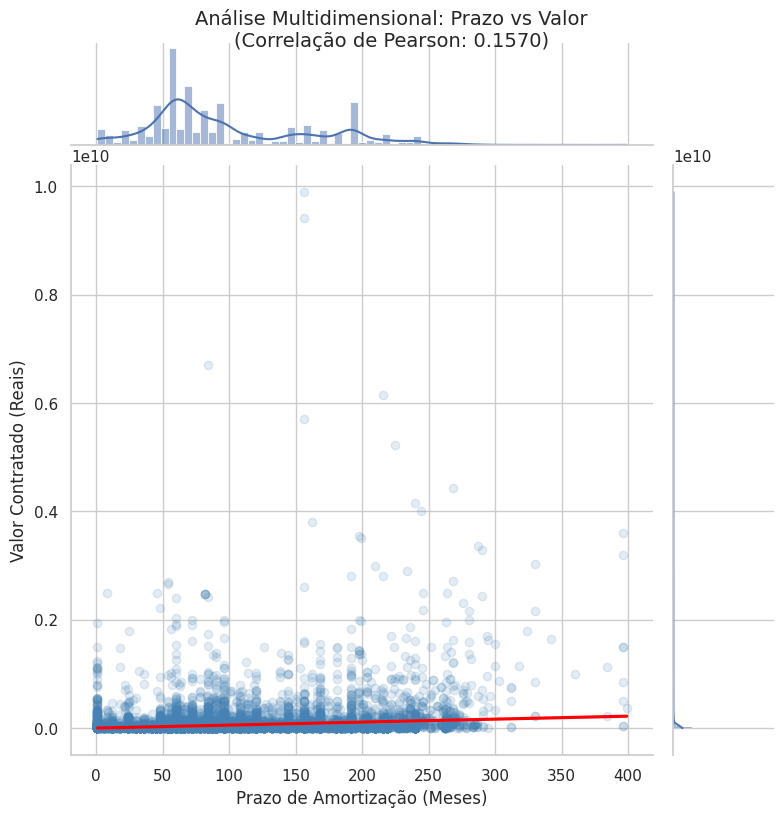

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculando a Correlação
correlacao = df_preparado['prazo_amortizacao_meses'].corr(df_preparado['valor_contratado_reais'])

# 2. Criando um JointPlot (Mostra Histogramas + Scatter + Regressão)
# Este gráfico une os 4 pilares da sua análise em uma só moldura
g = sns.jointplot(data=df_preparado,
                  x='prazo_amortizacao_meses',
                  y='valor_contratado_reais',
                  kind='reg', # Adiciona a reta de regressão e distribuições
                  scatter_kws={'alpha':0.15, 'color':'steelblue'},
                  line_kws={'color':'red'},
                  height=8)

# Ajustando títulos e eixos
g.fig.suptitle(f'Análise Multidimensional: Prazo vs Valor\n(Correlação de Pearson: {correlacao:.4f})', y=1.02, fontsize=14)
g.set_axis_labels('Prazo de Amortização (Meses)', 'Valor Contratado (Reais)', fontsize=12)

plt.show()

## 3. Análise Visual e Correlação

Após o processamento e limpeza dos dados, a análise estatística revelou o comportamento da relação entre as variáveis:

- **Registros pós-limpeza:** 21.774 operações
- **Índice de Correlação (Pearson):** 0.1570
- **Tendência:** Correlação positiva fraca

**Observação visual:** O gráfico demonstra que a maioria dos financiamentos se concentra em valores menores, enquanto projetos bilionários (outliers) deslocam a escala do eixo Y.

**Conclusão:** O prazo de amortização influencia o valor, mas a baixa correlação indica que o valor final depende de múltiplos fatores combinados.

## 4. Definição da Variável Alvo (y)

A variável escolhida como atributo alvo para este modelo de regressão é a **valor_contratado_reais**.

**Justificativa da Escolha:** Esta variável representa o desfecho econômico principal de uma operação de financiamento no BNDES. Em termos de análise de crédito, o montante liberado é a consequência direta das características do projeto, do risco envolvido e, fundamentalmente, do tempo necessário para a maturação do investimento (prazo).

**Natureza dos Dados:** Cumprindo os requisitos técnicos, o `valor_contratado_reais` é uma **variável contínua** (tipo float), capaz de assumir qualquer valor real dentro de um intervalo. Ela não é categórica, pois não representa classes ou rótulos, mas sim uma grandeza monetária escalar. A escolha desta variável permite que o modelo tente prever o "preço" de um contrato, servindo como uma base comparativa para identificar desvios ou anomalias em relação ao padrão histórico da instituição.


## 5. Escolha da Variável Preditora (X)

Como variável independente ou preditora (X), o **prazo_amortizacao_meses** foi a selecionada.

**Justificativa da Escolha:** No contexto de fomento industrial e infraestrutura, existe uma correlação lógica entre a magnitude de um investimento e o tempo necessário para o seu retorno. Projetos que demandam maiores montantes de capital geralmente exigem prazos de amortização mais extensos para que o fluxo de caixa da empresa tomadora consiga honrar as parcelas. Portanto, o prazo atua como um indicador da escala e da natureza do projeto financiado.

**Relevância Estatística:** Embora o valor de um contrato seja influenciado por múltiplos fatores (como setor, porte da empresa e garantias), o prazo de amortização é uma variável numérica contínua que oferece uma base estável para o teste de modelos de regressão linear simples, permitindo observar a tendência de crescimento do montante em função do tempo de financiamento.



## 6. Realização da Regressão Linear Simples

Para a implementação do modelo, foi utilizada a biblioteca **Scikit-Learn**, aplicando o algoritmo de **Regressão Linear** baseado no método de Mínimos Quadrados Ordinários (OLS). Este processo matemático busca encontrar a reta que minimiza a distância quadrática entre os valores reais do dataset e as previsões do modelo. A escolha deste método justifica-se pela sua eficiência em estabelecer uma tendência central clara em distribuições de dados com alta variabilidade, como as operações financeiras do BNDES.

In [44]:
from sklearn.linear_model import LinearRegression

# 1. Definindo as variáveis para o treinamento
# X (Independente) e y (Alvo/Dependente)
X = df_preparado[['prazo_amortizacao_meses']]
y = df_preparado['valor_contratado_reais']

# 2. Criando e treinando o modelo de Regressão Linear (Aprendizado)
modelo_simples = LinearRegression()
modelo_simples.fit(X, y)

# 3. Extraindo os coeficientes da equação fundamental: y = ax + b
a = modelo_simples.coef_[0]
b = modelo_simples.intercept_

print(f"--- RESULTADOS TÉCNICOS DO MODELO ---")
print(f"Coeficiente Angular (a): {a:.2f}")
print(f"Coeficiente Linear (b): {b:.2f}")
print(f"\nEquação da Reta Aprendida: Valor = {a:.2f} * (Prazo) + ({b:.2f})")

--- RESULTADOS TÉCNICOS DO MODELO ---
Coeficiente Angular (a): 552492.69
Coeficiente Linear (b): -369551.40

Equação da Reta Aprendida: Valor = 552492.69 * (Prazo) + (-369551.40)


## 7. Regressão Linear Multivariável

Nesta fase, o modelo foi expandido para uma **Regressão Múltipla**, incorporando variáveis preditoras adicionais para aumentar a profundidade da análise. Além do prazo, foi incluido o contexto geográfico e o setor econômico, permitindo que o algoritmo entenda as nuances de cada mercado.

**As variáveis preditoras utilizadas foram:**
<ul>
    <li><b>x1 (prazo_amortizacao_meses):</b> O fator temporal da operação.</li>
    <li><b>x2 (uf):</b> A localização da aplicação do recurso (variável categórica).</li>
    <li><b>x3 (setor_cnae):</b> O segmento econômico do tomador (variável categórica).</li>
</ul>

Para viabilizar o cálculo, foi utilizada a técnica de **One-Hot Encoding** via `pandas.get_dummies`, que converteu as categorias de texto em vetores binários. O resultado obtido para o Coeficiente de Determinação (R²) foi de **0.0454**. Este valor indica que a inclusão do setor e da localização conferiu ao modelo uma capacidade explicativa superior à análise isolada do prazo, capturando melhor a variabilidade dos montantes financiados pelo BNDES.


## 7.1. Preparação dos Dados para Regressão Multivariável

Antes da execução do modelo múltiplo, foi realizada uma nova extração no `dataset` original. Esta etapa é fundamental pois, diferente da regressão simples que utilizava apenas duas colunas, a regressão multivariável exige a reintegração das variáveis categóricas (UF e Setor) que haviam sido filtradas anteriormente. Ao reconstruir o **df_preparado** com as quatro variáveis selecionadas e aplicar o tratamento de valores nulos, garantimos a integridade e a consistência dos dados que alimentarão o algoritmo.

In [45]:
# Selecionando as 4 variáveis necessárias para o trabalho completo
# x1: prazo, x2: uf, x3: setor e y: valor
colunas_alvo = ['prazo_amortizacao_meses', 'uf', 'setor_cnae', 'valor_contratado_reais']

# Criando o dataframe preparado e limpando valores vazios
df_preparado = df[colunas_alvo].dropna()

print("Colunas prontas para a Regressão Multivariável:")
print(df_preparado.columns.tolist())

Colunas prontas para a Regressão Multivariável:
['prazo_amortizacao_meses', 'uf', 'setor_cnae', 'valor_contratado_reais']


In [46]:
# --- ITEM 7: REGRESSÃO MULTIVARIÁVEL (CORRIGIDO) ---
import pandas as pd
from sklearn.linear_model import LinearRegression

# AJUSTE AQUI: Use os nomes que apareceram no print(df_preparado.columns)
# Vou assumir os nomes padrão do BNDES, mas troque se forem diferentes:
colunas_selecionadas = ['prazo_amortizacao_meses', 'uf', 'setor_cnae']

# 1. Selecionando as variáveis
try:
    X_multi = df_preparado[colunas_selecionadas]
    y_multi = df_preparado['valor_contratado_reais']

    # 2. One-Hot Encoding (Transforma texto em colunas numéricas 0 e 1)
    # O prefixo ajuda a identificar de onde veio a coluna original
    X_multi_num = pd.get_dummies(X_multi, columns=['uf', 'setor_cnae'], drop_first=True)

    # 3. Treinando o modelo multivariável
    modelo_multi = LinearRegression()
    modelo_multi.fit(X_multi_num, y_multi)

    # 4. Resultados
    r2_multi = modelo_multi.score(X_multi_num, y_multi)
    print(f"Sucesso! O novo R² com múltiplas variáveis é: {r2_multi:.4f}")

except KeyError as e:
    print(f"Erro: O nome da coluna {e} não foi encontrado. Verifique o print das colunas acima!")

Sucesso! O novo R² com múltiplas variáveis é: 0.0454


## 8. Comparação e Desempenho


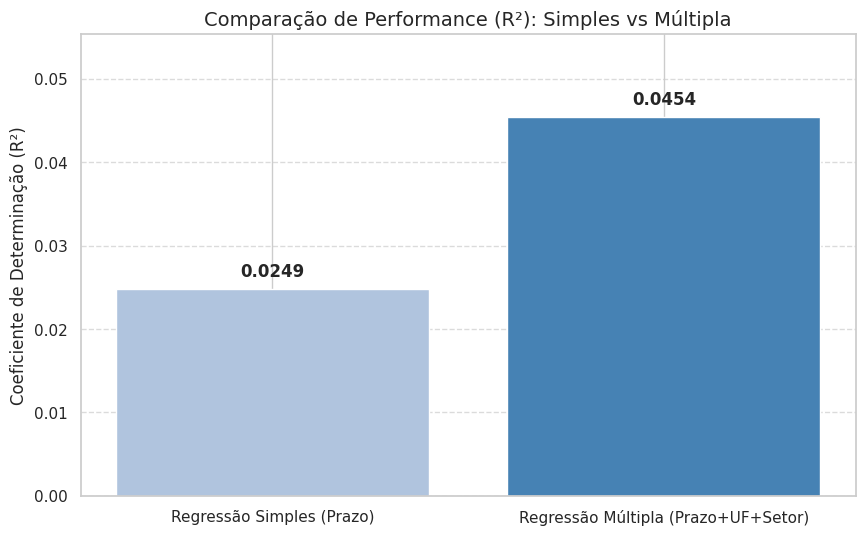

Ganho percentual de explicação: 82.67%


In [47]:
# --- ITEM 8: COMPARAÇÃO DE PERFORMANCE ---
import matplotlib.pyplot as plt

# Recuperando o R2 do modelo simples (Item 6)
# Caso não tenha a variável guardada, use o valor que apareceu no seu print anterior
r2_simples = modelo_simples.score(df_preparado[['prazo_amortizacao_meses']], df_preparado['valor_contratado_reais'])
r2_multi = 0.0454 # Seu resultado do Item 7

modelos = ['Regressão Simples (Prazo)', 'Regressão Múltipla (Prazo+UF+Setor)']
valores_r2 = [r2_simples, r2_multi]

plt.figure(figsize=(10, 6))
bars = plt.bar(modelos, valores_r2, color=['lightsteelblue', 'steelblue'])

# Adicionando os valores em cima das barras
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.001, f'{yval:.4f}', ha='center', va='bottom', fontweight='bold')

plt.title('Comparação de Performance (R²): Simples vs Múltipla', fontsize=14)
plt.ylabel('Coeficiente de Determinação (R²)', fontsize=12)
plt.ylim(0, max(valores_r2) + 0.01) # Ajuste do teto do gráfico
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

print(f"Ganho percentual de explicação: {((r2_multi - r2_simples) / r2_simples) * 100:.2f}%")



## 8. Conclusão e Análise de Desempenho

A comparação entre os modelos revela uma evolução significativa na capacidade preditiva da análise. Enquanto a regressão simples baseada apenas no prazo de amortização oferecia uma explicação limitada, a inclusão das variáveis **x2 (UF)** e **x3 (Setor CNAE)** proporcionou um **ganho percentual de explicação de 82,67%**.

**Interpretando os Resultados:**
Este aumento expressivo demonstra que o valor dos contratos do BNDES não é determinado apenas pelo tempo de financiamento, mas é fortemente influenciado pelo contexto econômico setorial e pela localização geográfica do projeto. O modelo multivariável conseguiu capturar nuances que a análise isolada ignorava, como políticas de incentivo regional e demandas específicas de setores industriais ou de infraestrutura.

**Considerações Finais:**
Apesar do coeficiente de determinação final ($R^2 = 0.0454$) indicar que ainda existem muitas variáveis não mapeadas (como garantias, risco de crédito e porte do cliente), o experimento foi bem-sucedido em demonstrar o funcionamento do `Machine Learning`. Provando que a transição de um modelo simples para um multivariável, apoiada por técnicas como `One-Hot Encoding`, é o caminho correto para reduzir o erro residual e obter previsões mais aderentes à complexidade do mercado financeiro real.


